In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df_placar2 = pd.read_csv("vlr_placar2.csv")
df_stats2 = pd.read_csv("vlr_stats2.csv")
df_geral = pd.read_csv('status_individual_geral.csv')

# ANÁLISE GRÁFICAS

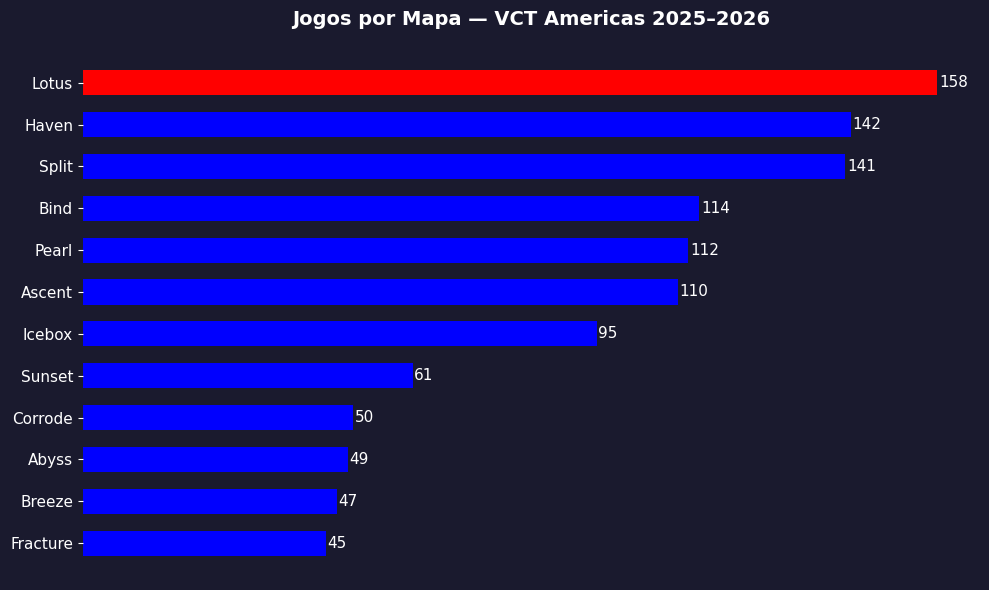

In [5]:
mapas = df_placar2["Mapa"].value_counts()

mapas = mapas.drop("AllMaps", errors="ignore")

mapas = mapas.sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

cores = ['red' if v == mapas.max() else 'blue' for v in mapas.values]

bars = ax.barh(mapas.index, mapas.values, color=cores, edgecolor='none', height=0.6)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va='center',
        fontsize=11,
        color='white'
    )


ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Jogos por Mapa — VCT Americas 2025–2026',
    color='white',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()


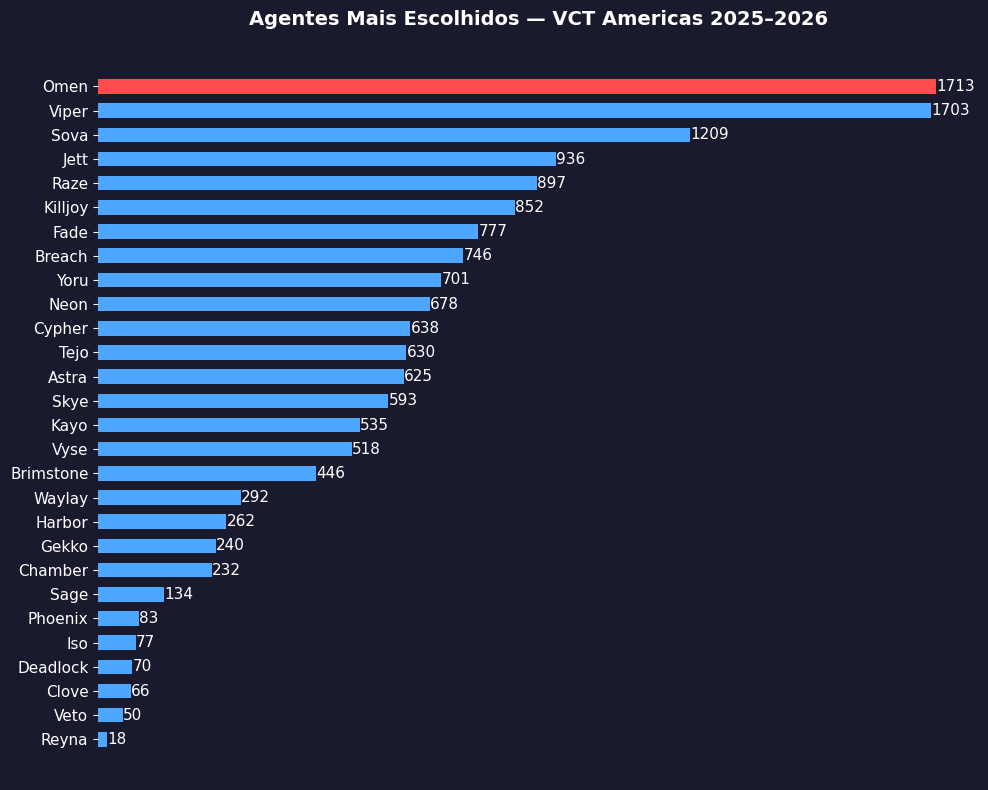

In [7]:
agentes = df_geral["Agente"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

cores = ['#ff4c4c' if v == agentes.max() else '#4da6ff' for v in agentes.values]

bars = ax.barh(agentes.index, agentes.values, color=cores, edgecolor='none', height=0.6)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va='center',
        fontsize=11,
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Agentes Mais Escolhidos — VCT Americas 2025–2026',
    color='white',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_69021/2983802163.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', n + 2)


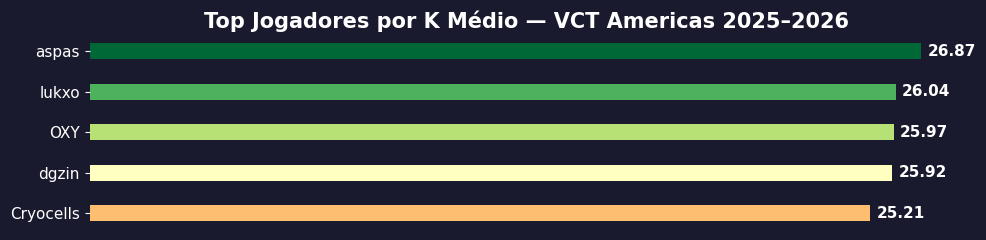

In [9]:
rating_por_jogador = (
    df_geral
    .groupby('Jogador')['K']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

n = len(rating_por_jogador)

fig, ax = plt.subplots(figsize=(10, n * 0.5))

cmap = plt.cm.get_cmap('RdYlGn', n + 2)
cores = [cmap(i + 2) for i in range(n)]

bars = ax.barh(
    rating_por_jogador.index[::-1],
    rating_por_jogador.values[::-1],
    color=cores,
    edgecolor='none',
    height=0.4
)

for bar, val in zip(bars, rating_por_jogador.values[::-1]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Top Jogadores por K Médio — VCT Americas 2025–2026',
    color='white',
    fontsize=15,
    fontweight='bold',
    pad=5
)

plt.tight_layout()
plt.show()


In [10]:
df_allmap = df_placar2[
    (df_placar2['Mapa'] == 'AllMaps') &
    (df_placar2['Mapas_T1'].notna()) &
    (df_placar2['Mapas_T2'].notna())
].drop_duplicates(subset='URL', keep='last')

total_rounds = df_allmap['Score_T1'].sum() + df_allmap['Score_T2'].sum()
print(f"Total de rounds jogados: {int(total_rounds)}")
print()

score_t1 = df_allmap.groupby('Time1')['Score_T1'].sum()
score_t2 = df_allmap.groupby('Time2')['Score_T2'].sum()

score_total = (
    score_t1
    .add(score_t2, fill_value=0)
    .sort_values(ascending=False)
    .astype(int)
)

print(score_total)


Total de rounds jogados: 16514

Time1
G2 Esports               1725
Sentinels                1632
100 Thieves              1619
LEVIATÁN                 1593
NRG                      1578
Cloud9                   1500
MIBR                     1348
LOUD                     1320
Evil Geniuses            1279
KRÜ Esports              1075
FURIA                    1030
VISA KRÜ(KRÜ Esports)     324
ENVY                      262
2Game Esports             229
dtype: int64


/tmp/ipykernel_69021/1893477881.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', len(score_total) + 2)


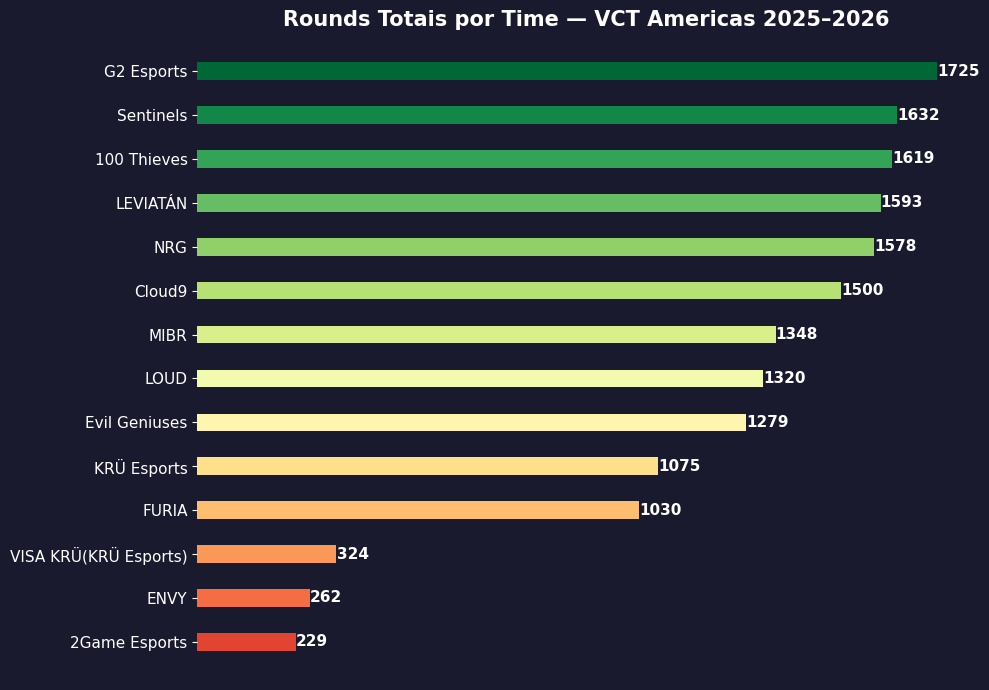

In [11]:
score_total = score_total.sort_values()

fig, ax = plt.subplots(figsize=(10, len(score_total) * 0.5))

cmap = plt.cm.get_cmap('RdYlGn', len(score_total) + 2)
cores = [cmap(i + 2) for i in range(len(score_total))]

bars = ax.barh(
    score_total.index,
    score_total.values,
    color=cores,
    edgecolor='none',
    height=0.4
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va='center',
        fontsize=11,
        fontweight='bold',
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Rounds Totais por Time — VCT Americas 2025–2026',
    color='white',
    fontsize=15,
    fontweight='bold',
    pad=5
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_69021/2352539959.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm', len(top_agente) + 2)


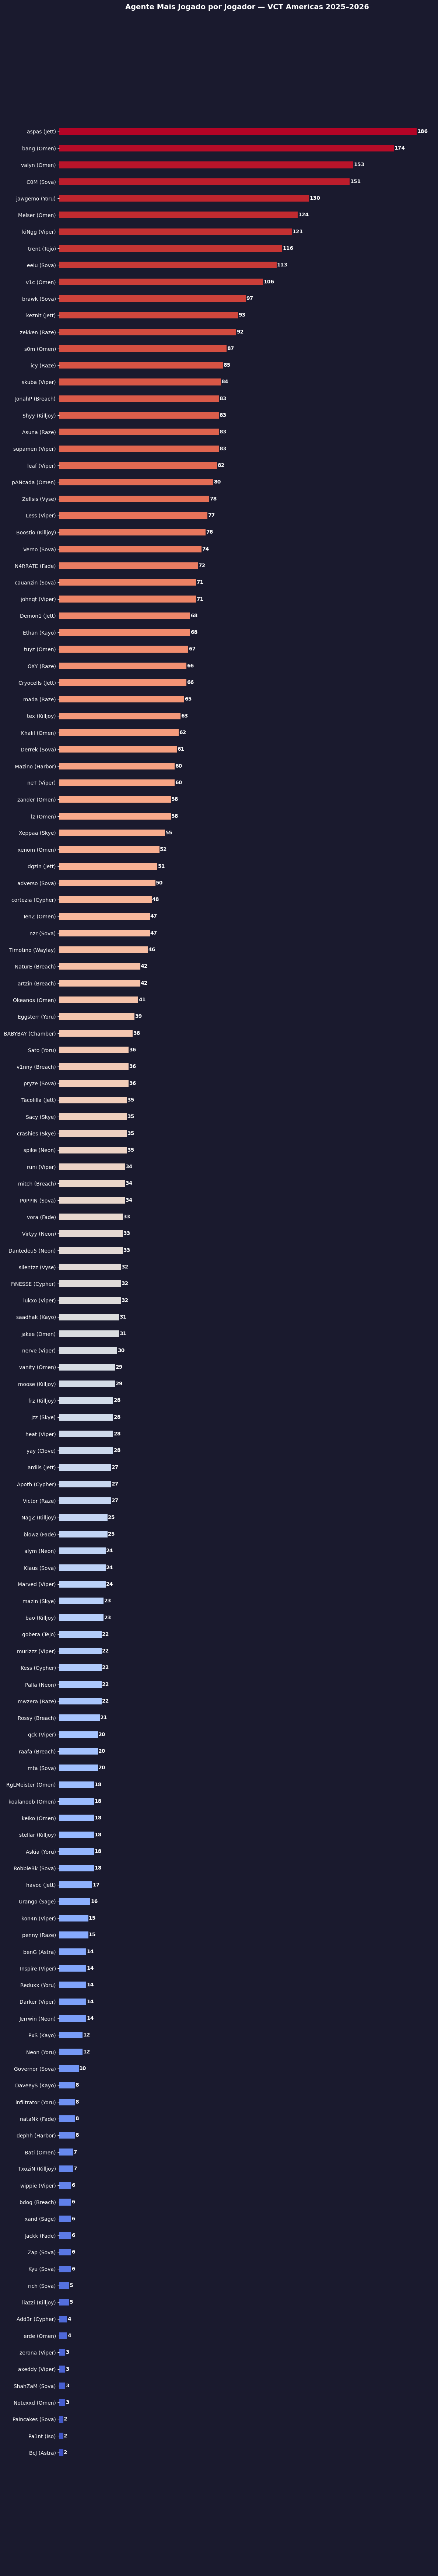

In [13]:
df_mapas = df_geral.copy()

agente_jogador = (
    df_mapas.groupby(['Jogador', 'Agente'])
    .size()
    .reset_index(name='Partidas')
    .sort_values('Partidas', ascending=False)
)

top_agente = (
    agente_jogador
    .groupby('Jogador')
    .first()
    .reset_index()
    .sort_values('Partidas')
)

fig, ax = plt.subplots(figsize=(12, len(top_agente) * 0.5))

cmap = plt.cm.get_cmap('coolwarm', len(top_agente) + 2)
cores = [cmap(i + 2) for i in range(len(top_agente))]

labels = [f"{row.Jogador} ({row.Agente})" for _, row in top_agente.iterrows()]

bars = ax.barh(
    labels,
    top_agente['Partidas'].values,
    color=cores,
    edgecolor='none',
    height=0.4
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=10)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Agente Mais Jogado por Jogador — VCT Americas 2025–2026',
    color='white',
    fontsize=14,
    fontweight='bold',
    pad=5
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_69021/2280415141.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', len(stats_agente) + 2)


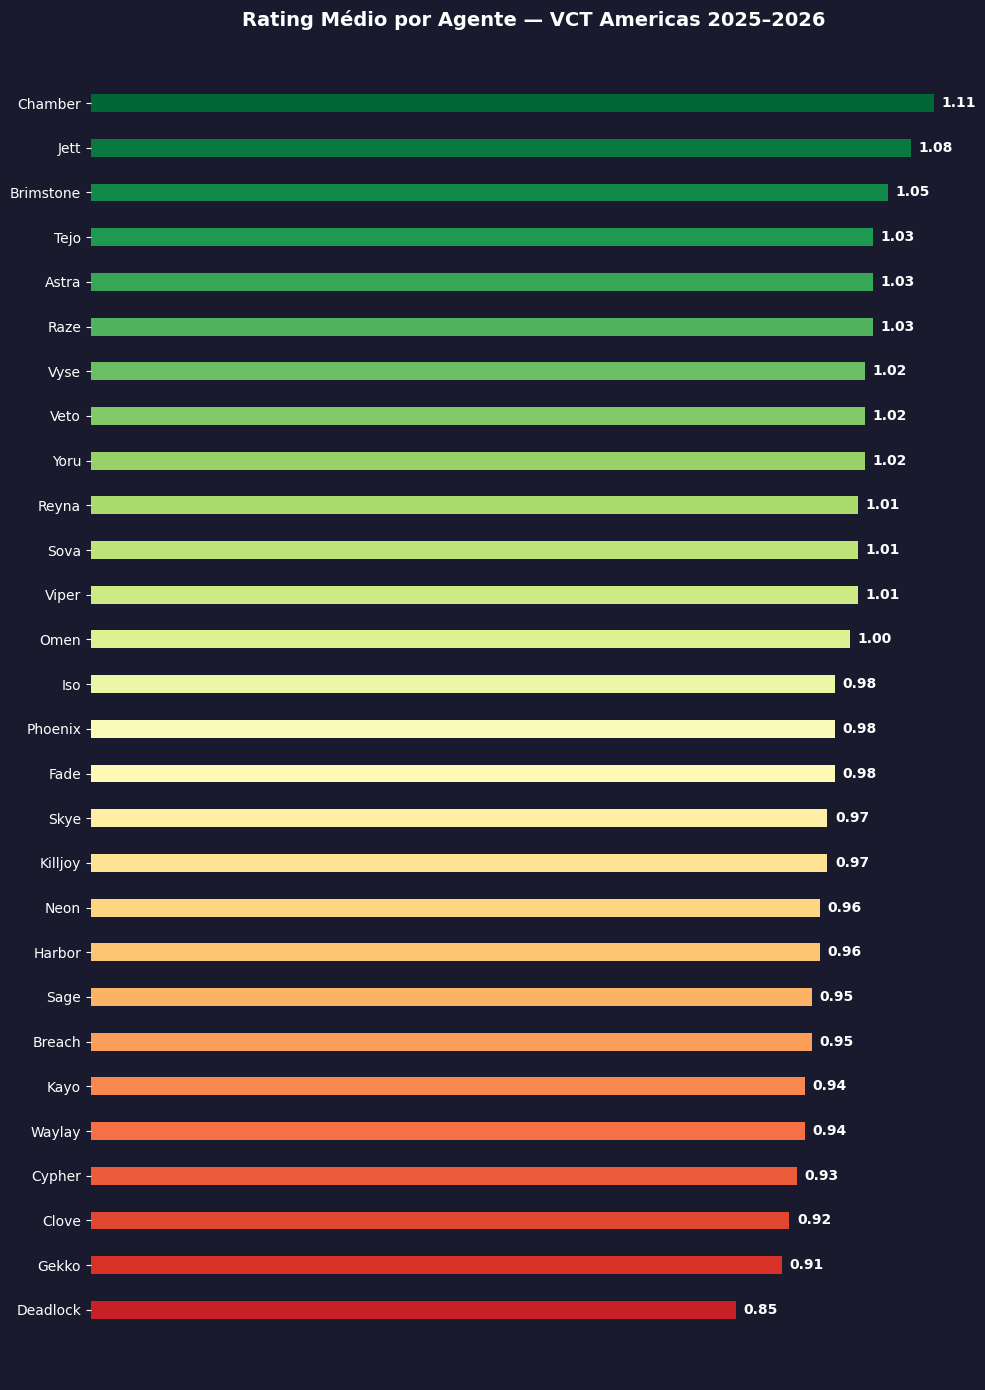

In [14]:
df_mapas = df_geral.copy()

stats_agente = (
    df_mapas.groupby('Agente')
    .agg(
        Partidas=('Agente', 'count'),
        Rating=('R', 'mean'),
        ACS=('ACS', 'mean'),
        KD=('K', 'sum'),
        Deaths=('D', 'sum'),
        KAST=('KAST', 'mean'),
        ADR=('ADR', 'mean'),
    )
    .assign(KD=lambda x: (x['KD'] / x['Deaths']).round(2))
    .query('Partidas >= 5')
    .sort_values('Rating')
    .round(2)
)

fig, ax = plt.subplots(figsize=(10, len(stats_agente) * 0.5))

cmap = plt.cm.get_cmap('RdYlGn', len(stats_agente) + 2)
cores = [cmap(i + 2) for i in range(len(stats_agente))]

bars = ax.barh(
    stats_agente.index,
    stats_agente['Rating'].values,
    color=cores,
    edgecolor='none',
    height=0.4
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=10)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Rating Médio por Agente — VCT Americas 2025–2026',
    color='white',
    fontsize=14,
    fontweight='bold',
    pad=5
)

plt.tight_layout()
plt.show()


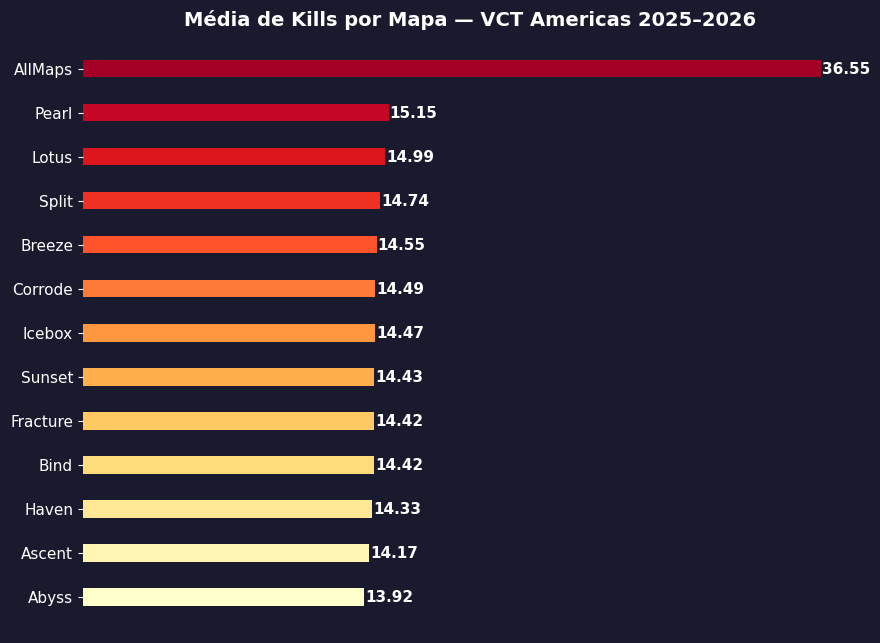

In [16]:
kills_por_mapa = (
    df_geral.groupby('Mapa')['K']
    .mean()
    .sort_values()
    .round(2)
)

fig, ax = plt.subplots(figsize=(10, max(len(kills_por_mapa) * 0.6, 4)))

cmap3 = plt.colormaps.get_cmap('YlOrRd')
cores3 = [cmap3(i / len(kills_por_mapa)) for i in range(len(kills_por_mapa))]

bars = ax.barh(
    kills_por_mapa.index,
    kills_por_mapa.values,
    color=cores3,
    edgecolor='none',
    height=0.4
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va='center',
        fontsize=11,
        fontweight='bold',
        color='white'
    )

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

ax.tick_params(colors='white', labelsize=11)
ax.spines[:].set_visible(False)
ax.xaxis.set_visible(False)

ax.set_title(
    'Média de Kills por Mapa — VCT Americas 2025–2026',
    color='white',
    fontsize=14,
    fontweight='bold',
    pad=5
)

plt.show()


In [20]:
df = df_placar2[df_placar2["Mapa"] != "AllMaps"].copy()

times = sorted(set(df["Time1"]).union(set(df["Time2"])))

wins  = pd.DataFrame(0, index=times, columns=times)
jogos = pd.DataFrame(0, index=times, columns=times)

for _, row in df.iterrows():
    t1, t2, v = row["Time1"], row["Time2"], row["Vencedor"]
    if t1 == t2 or pd.isna(v):
        continue
    jogos.loc[t1, t2] += 1
    jogos.loc[t2, t1] += 1
    if v == t1:
        wins.loc[t1, t2] += 1
    elif v == t2:
        wins.loc[t2, t1] += 1

# Lista de resultados
resultado = []

for t1 in times:
    for t2 in times:
        if t1 >= t2:
            continue
        n = jogos.loc[t1, t2]
        if n == 0:
            continue
        w1 = int(wins.loc[t1, t2])
        w2 = int(wins.loc[t2, t1])
        resultado.append(f"{t1} ganhou {w1}x e perdeu {w2}x contra {t2} — {w1/n*100:.0f}% de winrate ({n} mapas)")
        resultado.append(f"{t2} ganhou {w2}x e perdeu {w1}x contra {t1} — {w2/n*100:.0f}% de winrate ({n} mapas)")

for linha in sorted(resultado):
    print(linha)

100 Thieves ganhou 11x e perdeu 12x contra LEVIATÁN — 48% de winrate (23 mapas)
100 Thieves ganhou 11x e perdeu 15x contra G2 Esports — 42% de winrate (26 mapas)
100 Thieves ganhou 12x e perdeu 16x contra Sentinels — 43% de winrate (28 mapas)
100 Thieves ganhou 13x e perdeu 16x contra NRG — 45% de winrate (29 mapas)
100 Thieves ganhou 15x e perdeu 10x contra LOUD — 60% de winrate (25 mapas)
100 Thieves ganhou 18x e perdeu 1x contra Evil Geniuses — 95% de winrate (19 mapas)
100 Thieves ganhou 4x e perdeu 0x contra 2Game Esports — 100% de winrate (4 mapas)
100 Thieves ganhou 4x e perdeu 4x contra FURIA — 50% de winrate (8 mapas)
100 Thieves ganhou 4x e perdeu 4x contra VISA KRÜ(KRÜ Esports) — 50% de winrate (8 mapas)
100 Thieves ganhou 6x e perdeu 6x contra KRÜ Esports — 50% de winrate (12 mapas)
100 Thieves ganhou 6x e perdeu 8x contra Cloud9 — 43% de winrate (14 mapas)
100 Thieves ganhou 7x e perdeu 10x contra MIBR — 41% de winrate (17 mapas)
2Game Esports ganhou 0x e perdeu 4x contra 

In [21]:
rows = []

for t1 in times:
    for t2 in times:
        if t1 >= t2:
            continue
        n = jogos.loc[t1, t2]
        if n == 0:
            continue
        w1 = int(wins.loc[t1, t2])
        w2 = int(wins.loc[t2, t1])
        rows.append({"Time": t1, "Adversario": t2, "Vitorias": w1, "Derrotas": w2, "Mapas": int(n), "WinRate": round(w1/n*100, 1)})
        rows.append({"Time": t2, "Adversario": t1, "Vitorias": w2, "Derrotas": w1, "Mapas": int(n), "WinRate": round(w2/n*100, 1)})

df_matchups = pd.DataFrame(rows).sort_values(["Time", "Adversario"]).reset_index(drop=True)
# df_matchups.to_csv("matchups_score.csv", index=False)
df_matchups

,Time,Adversario,Vitorias,Derrotas,Mapas,WinRate
0,100 Thieves,2Game Esports,4,0,4,100.0
1,100 Thieves,Cloud9,6,8,14,42.9
2,100 Thieves,Evil Geniuses,18,1,19,94.7
3,100 Thieves,FURIA,4,4,8,50.0
4,100 Thieves,G2 Esports,11,15,26,42.3
...,...,...,...,...,...,...
151,VISA KRÜ(KRÜ Esports),LEVIATÁN,4,8,12,33.3
152,VISA KRÜ(KRÜ Esports),LOUD,8,4,12,66.7
153,VISA KRÜ(KRÜ Esports),MIBR,4,6,10,40.0
154,VISA KRÜ(KRÜ Esports),NRG,2,4,6,33.3


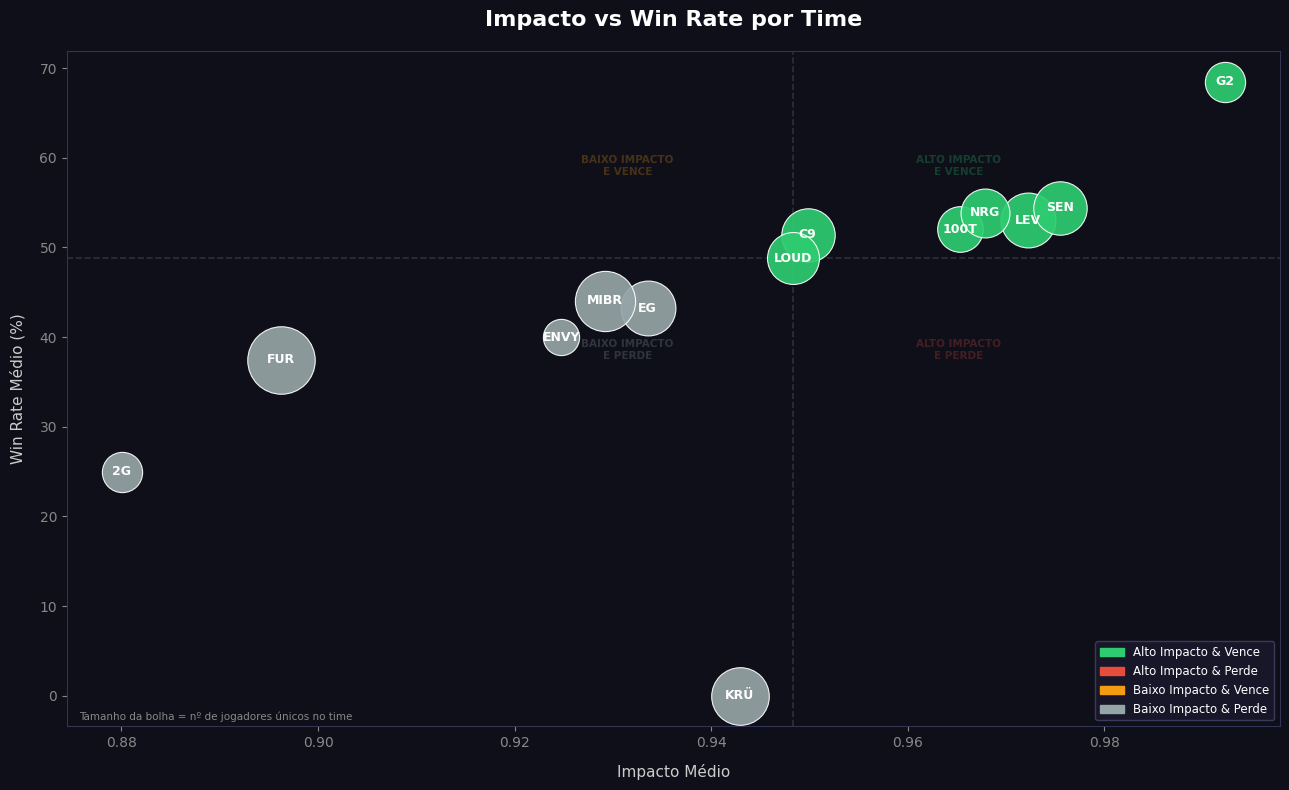

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df_impc = pd.read_csv("df_impacto_cada_mapa.csv")
df = df_impc.copy()

# ── Agregação por time ────────────────────────────────────────────────────────
df_time = (
    df.groupby("Time")
    .agg(
        Impacto_medio=("Impacto_Geral", "mean"),
        WinRate_medio=("target", "mean"),        # target 0/1 → média = win rate
        Jogadores=("Jogador", "nunique"),        # jogadores únicos por time
    )
    .reset_index()
)

df_time["WinRate_medio"] = df_time["WinRate_medio"] * 100  # converter para %

# ── Quadrantes (baseados na mediana) ─────────────────────────────────────────
med_impacto = df_time["Impacto_medio"].median()
med_winrate  = df_time["WinRate_medio"].median()

def quadrante(row):
    alto_imp = row["Impacto_medio"] >= med_impacto
    alta_wr  = row["WinRate_medio"]  >= med_winrate
    if alto_imp and alta_wr:
        return "Alto Impacto\n& Vence",  "#2ecc71"
    elif alto_imp and not alta_wr:
        return "Alto Impacto\n& Perde",  "#e74c3c"
    elif not alto_imp and alta_wr:
        return "Baixo Impacto\n& Vence", "#f39c12"
    else:
        return "Baixo Impacto\n& Perde", "#95a5a6"

df_time[["Quadrante", "Cor"]] = df_time.apply(quadrante, axis=1, result_type="expand")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("#0f0f1a")
ax.set_facecolor("#0f0f1a")

# Linhas dos quadrantes
ax.axvline(med_impacto, color="#ffffff22", linewidth=1.2, linestyle="--")
ax.axhline(med_winrate,  color="#ffffff22", linewidth=1.2, linestyle="--")

# Rótulos de fundo dos quadrantes
x_range = df_time["Impacto_medio"].max() - df_time["Impacto_medio"].min()
y_range = df_time["WinRate_medio"].max()  - df_time["WinRate_medio"].min()

quadrante_labels = [
    (med_impacto + x_range * 0.15, med_winrate + y_range * 0.15, "ALTO IMPACTO\nE VENCE",  "#2ecc71"),
    (med_impacto - x_range * 0.15, med_winrate + y_range * 0.15, "BAIXO IMPACTO\nE VENCE", "#f39c12"),
    (med_impacto + x_range * 0.15, med_winrate - y_range * 0.15, "ALTO IMPACTO\nE PERDE",  "#e74c3c"),
    (med_impacto - x_range * 0.15, med_winrate - y_range * 0.15, "BAIXO IMPACTO\nE PERDE", "#95a5a6"),
]

for x, y, txt, cor in quadrante_labels:
    ax.text(x, y, txt, fontsize=7.5, color=cor,
            ha="center", va="center", fontweight="bold", alpha=0.25)

# Scatter por time
for _, row in df_time.iterrows():
    tamanho = 200 + row["Jogadores"] * 80
    ax.scatter(
        row["Impacto_medio"], row["WinRate_medio"],
        s=tamanho, color=row["Cor"], edgecolors="white",
        linewidths=0.8, alpha=0.92, zorder=3
    )
    ax.annotate(
        row["Time"],
        xy=(row["Impacto_medio"], row["WinRate_medio"]),
        xytext=(0, 0), textcoords="offset points",
        ha="center", va="center",
        fontsize=9, color="white", fontweight="bold",
        zorder=4
    )

# ── Estética ──────────────────────────────────────────────────────────────────
ax.set_xlabel("Impacto Médio", fontsize=11, color="#cccccc", labelpad=10)
ax.set_ylabel("Win Rate Médio (%)", fontsize=11, color="#cccccc", labelpad=10)
ax.set_title(
    "Impacto vs Win Rate por Time",
    fontsize=16, color="white", fontweight="bold", pad=18
)
ax.tick_params(colors="#888888")
for spine in ax.spines.values():
    spine.set_edgecolor("#333355")

# Legenda
patches = [
    mpatches.Patch(color="#2ecc71", label="Alto Impacto & Vence"),
    mpatches.Patch(color="#e74c3c", label="Alto Impacto & Perde"),
    mpatches.Patch(color="#f39c12", label="Baixo Impacto & Vence"),
    mpatches.Patch(color="#95a5a6", label="Baixo Impacto & Perde"),
]
ax.legend(
    handles=patches, loc="lower right", fontsize=8.5,
    facecolor="#1a1a2e", edgecolor="#444466", labelcolor="white"
)
ax.text(
    0.01, 0.01,
    "Tamanho da bolha = nº de jogadores únicos no time",
    transform=ax.transAxes, fontsize=7.5, color="#888888"
)

plt.tight_layout()
plt.show()

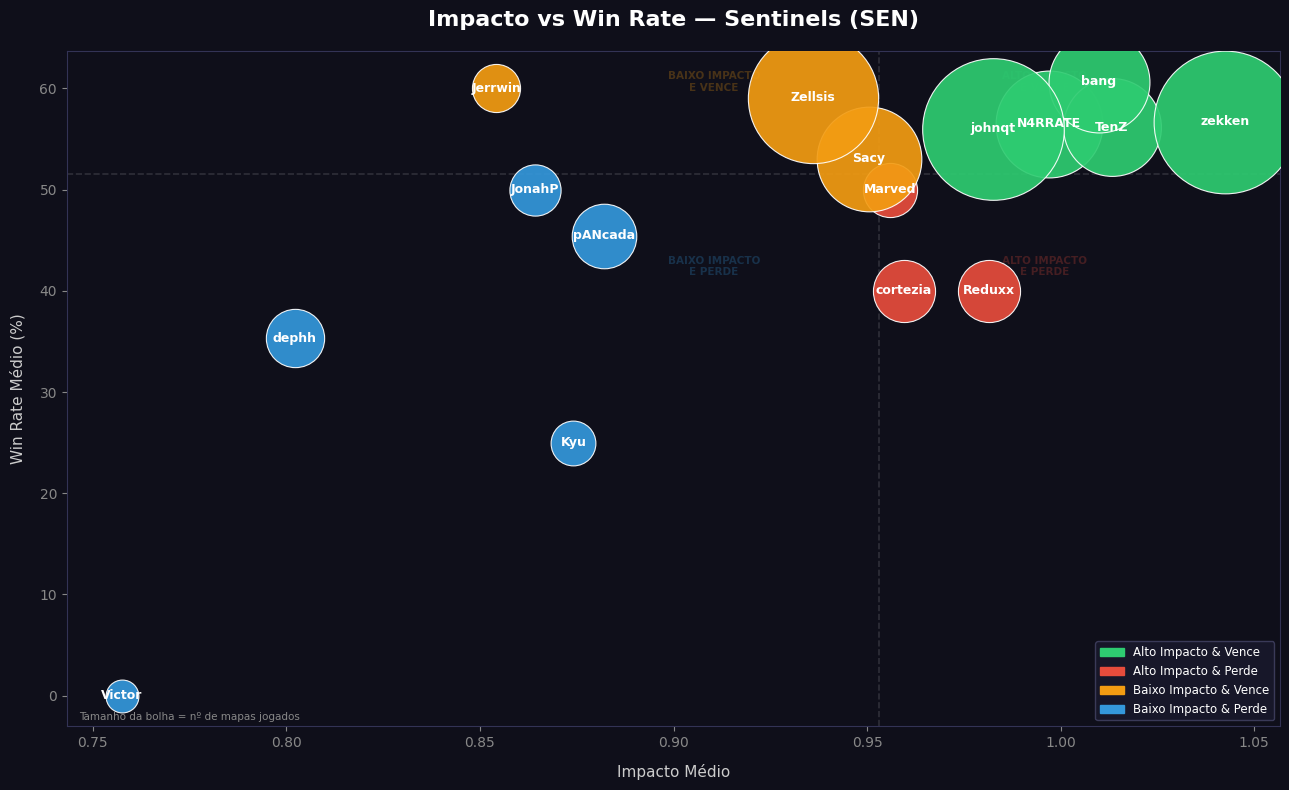

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df_impc = pd.read_csv("df_impacto_cada_mapa.csv")

tag = {
    'SEN':  'Sentinels',
    'NRG':  'NRG',
    'C9':   'Cloud9',
    'FUR':  'FURIA',
    'LEV':  'LEVIATÁN',
    'EG':   'Evil Geniuses',
    '100T': '100 Thieves',
    'KRU':  'KRÜ Esports',
    'G2':   'G2 Esports',
    'ENVY': 'ENVY',
    'MIBR': 'MIBR',
    'LOUD': 'LOUD',
    '2G':   '2Game Esports',
}

TIME_SELECIONADO = "SEN"
TIME_NOME = tag.get(TIME_SELECIONADO.upper(), TIME_SELECIONADO)

df_filtrado = df_impc[df_impc["Time"] == TIME_SELECIONADO].copy()

if df_filtrado.empty:
    raise ValueError(
        f"Time '{TIME_SELECIONADO}' não encontrado.\n"
        f"Tags disponíveis: {sorted(df_impc['Time'].unique().tolist())}"
    )

# ── Agrega por jogador ────────────────────────────────────────────────────────
df_jog = (
    df_filtrado.groupby("Jogador")
    .agg(
        Impacto_medio=("Impacto_Geral", "mean"),      # ← corrigido
        WinRate_medio=("target", "mean"),              # ← corrigido
        Mapas=("Mapa", "count"),
    )
    .reset_index()
)

df_jog["WinRate_medio"] = df_jog["WinRate_medio"] * 100  # converter para %

# ── Quadrantes ────────────────────────────────────────────────────────────────
med_impacto = df_jog["Impacto_medio"].median()
med_winrate  = df_jog["WinRate_medio"].median()

def quadrante(row):
    alto_imp = row["Impacto_medio"] >= med_impacto
    alta_wr  = row["WinRate_medio"]  >= med_winrate
    if alto_imp and alta_wr:
        return "Alto Impacto & Vence",  "#2ecc71"
    elif alto_imp and not alta_wr:
        return "Alto Impacto & Perde",  "#e74c3c"
    elif not alto_imp and alta_wr:
        return "Baixo Impacto & Vence", "#f39c12"
    else:
        return "Baixo Impacto & Perde", "#3498db"

df_jog[["Quadrante", "Cor"]] = df_jog.apply(
    quadrante, axis=1, result_type="expand"
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("#0f0f1a")
ax.set_facecolor("#0f0f1a")

ax.axvline(med_impacto, color="#ffffff22", linewidth=1.2, linestyle="--")
ax.axhline(med_winrate,  color="#ffffff22", linewidth=1.2, linestyle="--")

x_range = df_jog["Impacto_medio"].max() - df_jog["Impacto_medio"].min()
y_range = df_jog["WinRate_medio"].max()  - df_jog["WinRate_medio"].min()

quadrante_labels = [
    (med_impacto + x_range * 0.15, med_winrate + y_range * 0.15, "ALTO IMPACTO\nE VENCE",  "#2ecc71"),
    (med_impacto - x_range * 0.15, med_winrate + y_range * 0.15, "BAIXO IMPACTO\nE VENCE", "#f39c12"),
    (med_impacto + x_range * 0.15, med_winrate - y_range * 0.15, "ALTO IMPACTO\nE PERDE",  "#e74c3c"),
    (med_impacto - x_range * 0.15, med_winrate - y_range * 0.15, "BAIXO IMPACTO\nE PERDE", "#3498db"),
]
for x, y, txt, cor in quadrante_labels:
    ax.text(x, y, txt, fontsize=7.5, color=cor,
            ha="center", va="center", fontweight="bold", alpha=0.25)

for _, row in df_jog.iterrows():
    tamanho = 400 + row["Mapas"] * 80
    ax.scatter(
        row["Impacto_medio"], row["WinRate_medio"],
        s=tamanho, color=row["Cor"], edgecolors="white",
        linewidths=0.8, alpha=0.92, zorder=3
    )
    ax.annotate(
        row["Jogador"],
        xy=(row["Impacto_medio"], row["WinRate_medio"]),
        xytext=(0, 0), textcoords="offset points",
        ha="center", va="center",
        fontsize=9, color="white", fontweight="bold",
        zorder=4
    )

ax.set_xlabel("Impacto Médio", fontsize=11, color="#cccccc", labelpad=10)
ax.set_ylabel("Win Rate Médio (%)", fontsize=11, color="#cccccc", labelpad=10)
ax.set_title(
    f"Impacto vs Win Rate — {TIME_NOME} ({TIME_SELECIONADO})",
    fontsize=16, color="white", fontweight="bold", pad=18
)
ax.tick_params(colors="#888888")
for spine in ax.spines.values():
    spine.set_edgecolor("#333355")

patches = [
    mpatches.Patch(color="#2ecc71", label="Alto Impacto & Vence"),
    mpatches.Patch(color="#e74c3c", label="Alto Impacto & Perde"),
    mpatches.Patch(color="#f39c12", label="Baixo Impacto & Vence"),
    mpatches.Patch(color="#3498db", label="Baixo Impacto & Perde"),
]
ax.legend(
    handles=patches, loc="lower right", fontsize=8.5,
    facecolor="#1a1a2e", edgecolor="#444466", labelcolor="white"
)
ax.text(
    0.01, 0.01,
    "Tamanho da bolha = nº de mapas jogados",
    transform=ax.transAxes, fontsize=7.5, color="#888888"
)

plt.tight_layout()
plt.show()